# Detecção de Fraude em Transações de Cartão de Crédito
### Projeto pessoal de Data Wrangling & PCA

**Contexto do projeto**

Este exericício de preparação de dados faz parte da formação MCIO + Leega
para Engenharia de dados.

A formação inclui:
1. Fundamentos de dados
2. Preparação de dados
3. Engenharia e Arquitetura de dados
4. Visualização e storytelling de dados

Este projeto replica, com um dataset próprio e gerado de forma independente, o mesmo
fluxo técnico de preparação de dados aplicado a um cenário de detecção de fraude em
transações de cartão de crédito - inspirado no que estudei no módulo de Data Wrangling &
PCA da minha formação em Dados (Leega + MCIO+).

**Dataset:** gerado sinteticamente (não é o dataset usado em sala de aula), com estrutura
equivalente: variáveis numéricas anonimizadas (`V1`...`V28`), além de `Time`, `Amount` e
`Class` (0 = não fraude, 1 = fraude).

**Requisitos do projeto (os mesmos aplicados na aula):**
1. Analisar a correlação entre as variáveis do dataset.
2. Padronizar `Amount`, `Time` (e demais colunas numéricas).
3. Aplicar PCA para reduzir o dataset a 2 componentes principais.
4. Balancear a amostra (undersampling) e separar em treino (80%) e teste (20%).


## 1. Geração do dataset sintético

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

N_SAMPLES = 60000
N_FEATURES = 28  # V1...V28
FRAUD_RATIO = 0.0035  # ~0.35% de fraude (diferente da base original, mas também bem desbalanceada)

X, y = make_classification(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    n_informative=10,
    n_redundant=6,
    n_repeated=0,
    n_clusters_per_class=2,
    weights=[1 - FRAUD_RATIO, FRAUD_RATIO],
    flip_y=0.001,
    class_sep=1.1,
    random_state=RANDOM_STATE,
)

df = pd.DataFrame(X, columns=[f'V{i}' for i in range(1, N_FEATURES + 1)])
df['Class'] = y

# Time: segundos desde a primeira transação, ao longo de ~3 dias
df['Time'] = np.sort(np.random.randint(0, 3 * 24 * 3600, size=N_SAMPLES))

# Amount: valores de transação com distribuição assimétrica (lognormal),
# com fraudes tendendo a valores um pouco mais altos, em média
base_amount = np.random.lognormal(mean=3.0, sigma=1.1, size=N_SAMPLES)
fraud_bump = np.where(df['Class'] == 1, np.random.lognormal(mean=4.0, sigma=0.8, size=N_SAMPLES), 0)
df['Amount'] = np.round(base_amount + fraud_bump, 2)

# Reordena colunas no mesmo padrão do dataset original: Time, V1...V28, Amount, Class
cols = ['Time'] + [f'V{i}' for i in range(1, N_FEATURES + 1)] + ['Amount', 'Class']
df = df[cols]

import os
os.makedirs('../data', exist_ok=True)
df.to_csv('../data/transacoes_cartao.csv', index=False)
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,5,1.811078,-0.089118,-0.495102,-0.107484,-0.670231,-1.616841,-0.482660,-3.168471,0.077986,...,2.192553,5.235341,0.055867,-0.695421,0.829426,0.987217,0.176960,-0.933289,7.98,0
1,10,-3.718862,0.037726,-0.589234,3.399618,-1.363438,1.176960,0.608483,5.922289,-0.028194,...,-0.023242,-0.462728,2.829688,0.880120,0.059043,-0.340281,-0.469687,-1.309975,15.05,0
2,15,0.330682,-0.316498,-0.678355,-0.703325,0.640769,-0.520664,-1.761073,-1.715715,0.615178,...,0.198884,1.333756,-2.112984,-1.128802,1.196218,-1.059028,0.695277,-2.638208,39.55,0
3,15,-1.887250,0.138673,0.346975,-2.371275,1.361138,-0.298077,-0.656177,-2.325238,0.555514,...,-0.413725,-1.167068,-4.443594,0.384604,-0.896667,-0.044446,-0.212894,0.681116,9.26,0
4,16,5.547823,0.497639,-0.848782,0.935216,-4.148959,-0.177286,-0.784711,-1.294608,0.018469,...,-0.149310,-0.443327,9.143350,0.422273,1.296923,-0.869582,-0.545519,1.526828,41.08,0


## 2. Distribuição de Fraude x Não Fraude

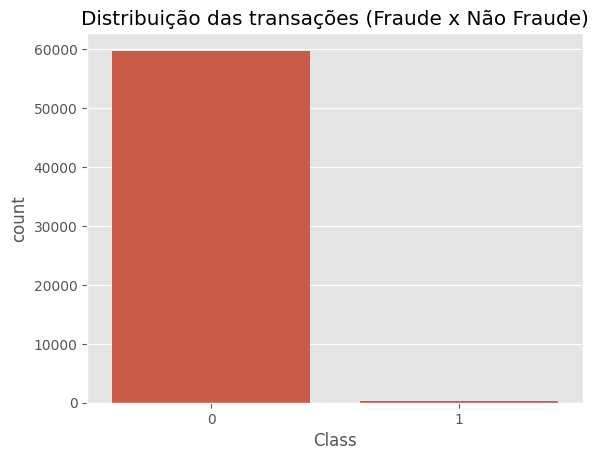

Fraudes : 237
Nao fraudes : 59763
Fraudes : 0.395 %
Nao fraudes : 99.605 %


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

All = df.shape[0]
fraud = df[df['Class'] == 1]
nonFraud = df[df['Class'] == 0]
x = len(fraud) / All
y_ = len(nonFraud) / All

sns.countplot(x='Class', data=df)
plt.title('Distribuição das transações (Fraude x Não Fraude)')
plt.show()

print('Fraudes :', len(fraud))
print('Nao fraudes :', len(nonFraud))
print('Fraudes :', x * 100, '%')
print('Nao fraudes :', y_ * 100, '%')


## 3. Matriz de Correlação

Objetivo: entender se existe correlação entre as variáveis do dataset, o que ajuda a
identificar quais características são relevantes e quais são redundantes ou irrelevantes.


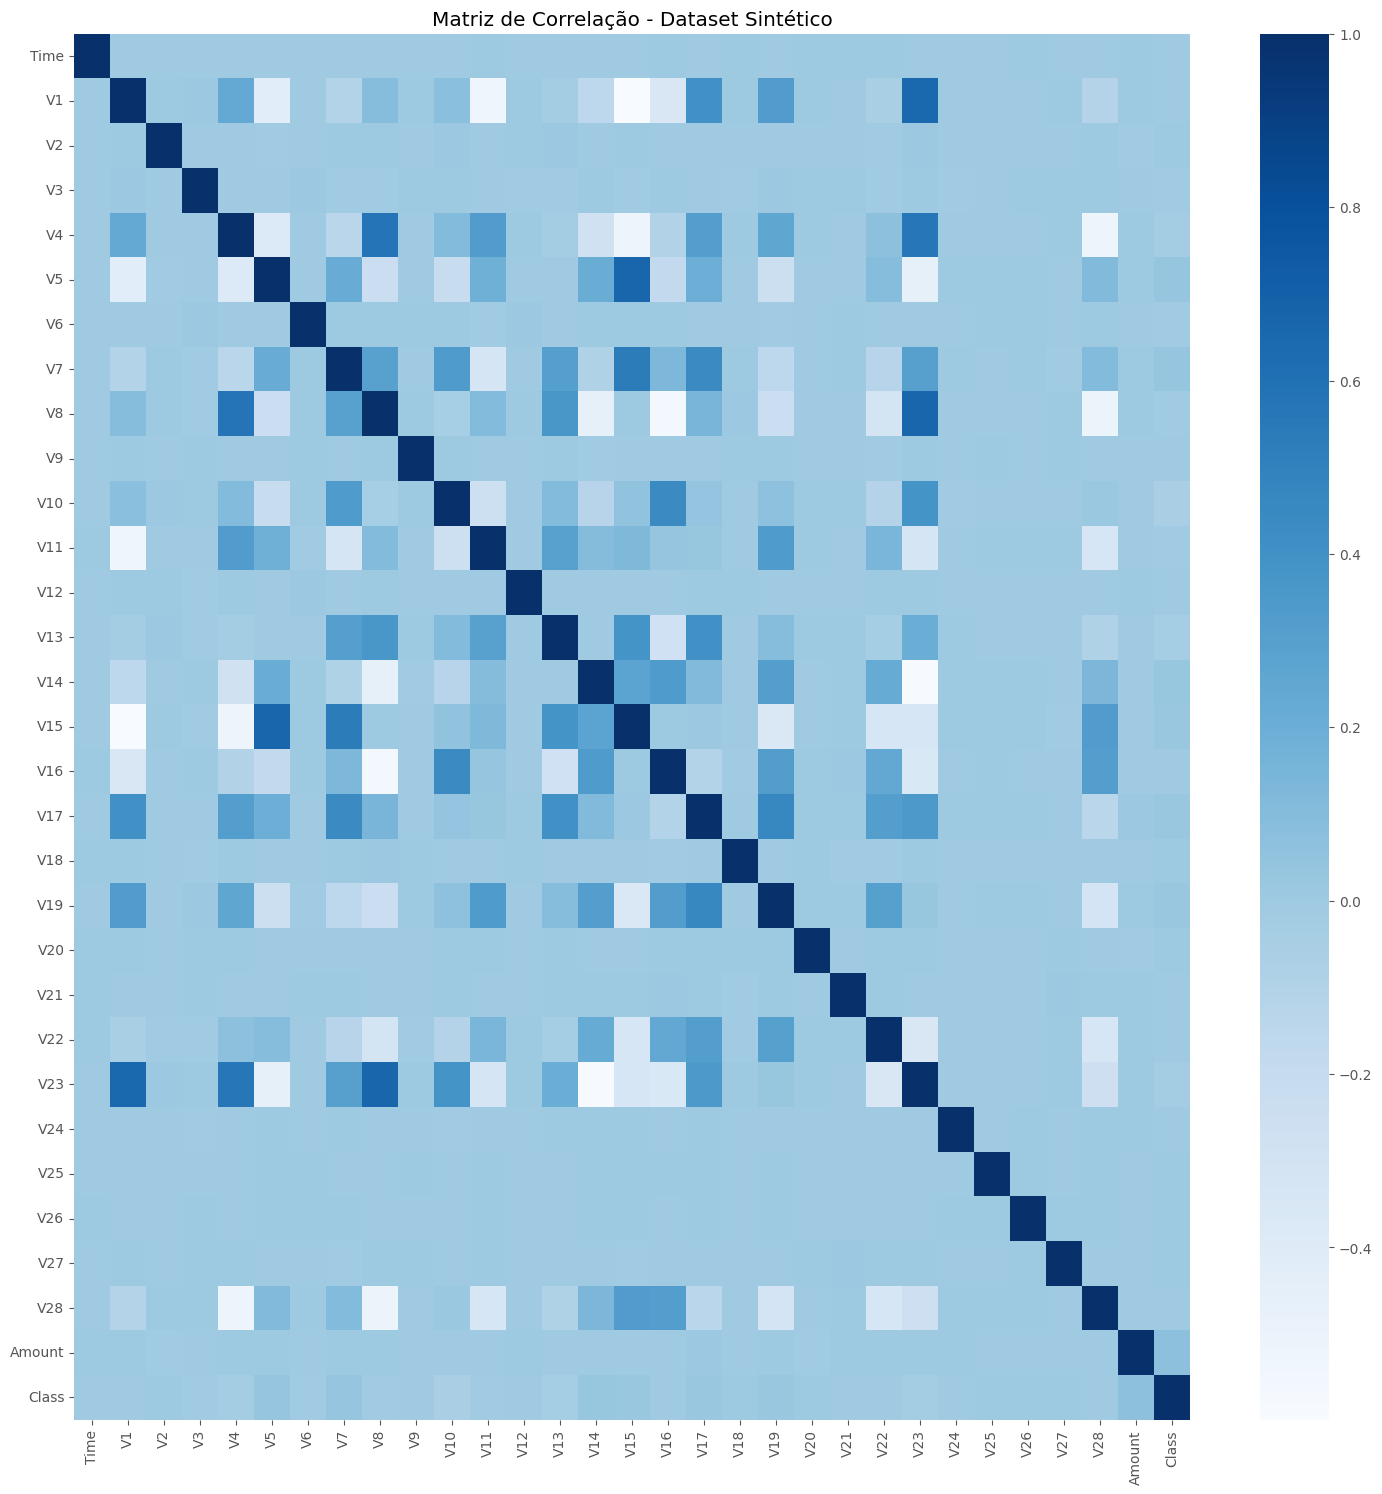

In [3]:
correlation_matrix = df.corr()
plt.figure(figsize=(18, 18))
sns.heatmap(correlation_matrix, cbar=True, fmt='.1f', annot=False, cmap='Blues')
plt.title('Matriz de Correlação - Dataset Sintético')
plt.show()


## 4. Padronização (StandardScaler)

`Amount` e `Time` são padronizados (média 0, desvio-padrão 1); as colunas originais são substituídas.

In [4]:
from sklearn.preprocessing import StandardScaler

df['Vamount'] = StandardScaler().fit_transform(df['Amount'].values.reshape(-1, 1))
df['Vtime'] = StandardScaler().fit_transform(df['Time'].values.reshape(-1, 1))
df = df.drop(['Time', 'Amount'], axis=1)
df.head()


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Vamount,Vtime
0,1.811078,-0.089118,-0.495102,-0.107484,-0.670231,-1.616841,-0.482660,-3.168471,0.077986,2.953655,...,5.235341,0.055867,-0.695421,0.829426,0.987217,0.176960,-0.933289,0,-0.534886,-1.726683
1,-3.718862,0.037726,-0.589234,3.399618,-1.363438,1.176960,0.608483,5.922289,-0.028194,0.792400,...,-0.462728,2.829688,0.880120,0.059043,-0.340281,-0.469687,-1.309975,0,-0.404771,-1.726616
2,0.330682,-0.316498,-0.678355,-0.703325,0.640769,-0.520664,-1.761073,-1.715715,0.615178,-0.786028,...,1.333756,-2.112984,-1.128802,1.196218,-1.059028,0.695277,-2.638208,0,0.046124,-1.726549
3,-1.887250,0.138673,0.346975,-2.371275,1.361138,-0.298077,-0.656177,-2.325238,0.555514,0.035121,...,-1.167068,-4.443594,0.384604,-0.896667,-0.044446,-0.212894,0.681116,0,-0.511329,-1.726549
4,5.547823,0.497639,-0.848782,0.935216,-4.148959,-0.177286,-0.784711,-1.294608,0.018469,5.007507,...,-0.443327,9.143350,0.422273,1.296923,-0.869582,-0.545519,1.526828,0,0.074282,-1.726536


## 5. PCA — Redução para 2 componentes principais

In [5]:
from sklearn.decomposition import PCA

X_full = df.drop(['Class'], axis=1)
y_full = df['Class']

pca = PCA(n_components=2)
principalComponents = pca.fit_transform(X_full.values)
principalDf = pd.DataFrame(data=principalComponents, columns=['principal component 1', 'principal component 2'])
finalDf = pd.concat([principalDf, y_full], axis=1)
finalDf.head()


,principal component 1,principal component 2,Class
0,1.598690,-5.510781,0
1,1.283915,4.413143,0
2,-0.568174,-3.179183,0
3,-8.764950,1.755299,0
4,12.317988,-5.409853,0


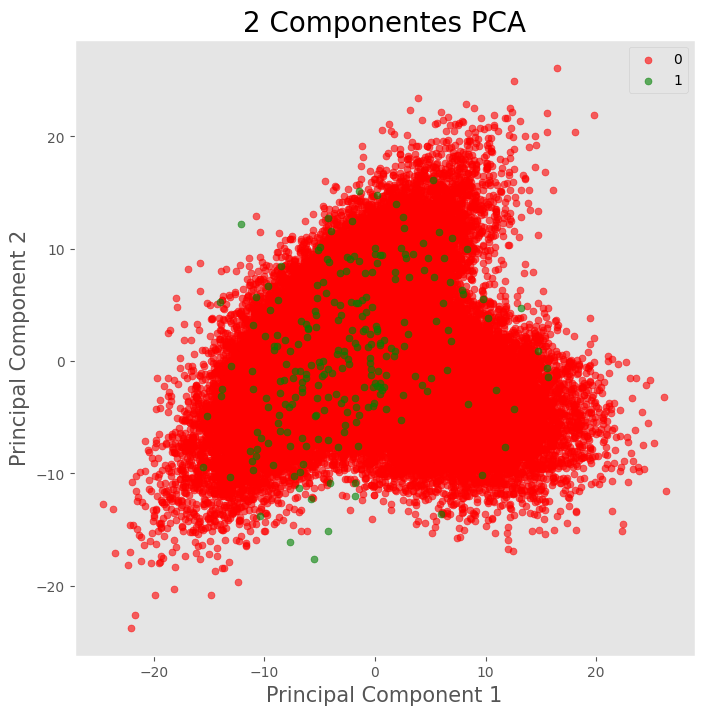

Variância explicada por componente: [0.30660816 0.19858132]
Variância total explicada pelos 2 componentes: 0.5051894876248286


In [6]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1)
ax.set_xlabel('Principal Component 1', fontsize=15)
ax.set_ylabel('Principal Component 2', fontsize=15)
ax.set_title('2 Componentes PCA', fontsize=20)
targets = [0, 1]
colors = ['r', 'g']
for target, color in zip(targets, colors):
    indicesToKeep = finalDf['Class'] == target
    ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1'],
               finalDf.loc[indicesToKeep, 'principal component 2'],
               c=color, s=25, alpha=0.6)
ax.legend(targets)
ax.grid()
plt.show()

print('Variância explicada por componente:', pca.explained_variance_ratio_)
print('Variância total explicada pelos 2 componentes:', sum(pca.explained_variance_ratio_))


## 6. Balanceamento da base (undersampling)

Mantemos todos os casos de fraude e selecionamos um número igual de casos não-fraude, para não enviesar o modelo.

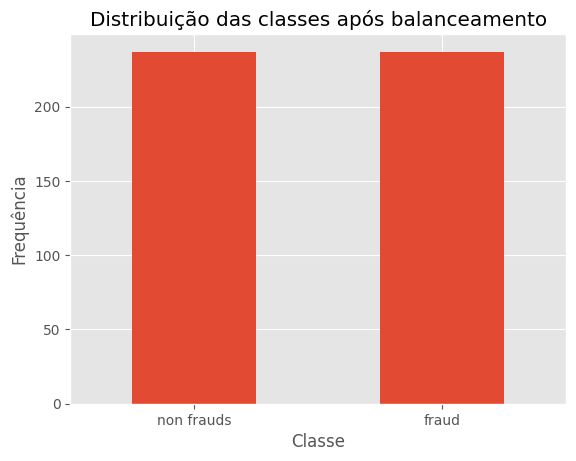

Class
1    237
0    237
Name: count, dtype: int64


In [7]:
df_shuffled = df.sample(frac=1, random_state=RANDOM_STATE)
frauds = df_shuffled[df_shuffled['Class'] == 1]
n_frauds = len(frauds)
non_frauds = df_shuffled[df_shuffled['Class'] == 0][:n_frauds]
new_df = pd.concat([non_frauds, frauds])
new_df = new_df.sample(frac=1, random_state=RANDOM_STATE)

labels = ['non frauds', 'fraud']
classes = new_df['Class'].value_counts(sort=True)
classes.plot(kind='bar', rot=0)
plt.title('Distribuição das classes após balanceamento')
plt.xticks(range(2), labels)
plt.xlabel('Classe')
plt.ylabel('Frequência')
plt.show()

print(new_df['Class'].value_counts())


## 7. Geração da base de treino e teste (80/20)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize

features = new_df.drop(['Class'], axis=1)
labels = pd.DataFrame(new_df['Class'])
feature_array = features.values
label_array = labels.values

X_train, X_test, y_train, y_test = train_test_split(
    feature_array, label_array, test_size=0.20, random_state=RANDOM_STATE
)

X_train = normalize(X_train)
X_test = normalize(X_test)

print('Shape treino:', X_train.shape)
print('Shape teste:', X_test.shape)


Shape treino: (379, 30)
Shape teste: (95, 30)


## 8. Conclusão

Com a base padronizada, reduzida via PCA e balanceada, os dados estão prontos para
alimentar um modelo de classificação (ex.: KNN, Regressão Logística, Random Forest).

**O que este projeto demonstra:**
- Análise de correlação para entender relações entre variáveis.
- Padronização de variáveis com `StandardScaler`.
- Redução de dimensionalidade com `PCA`.
- Tratamento de bases desbalanceadas via undersampling.
- Separação correta em treino e teste, com normalização aplicada **depois** do split
  (evitando vazamento de dados / data leakage).

Próximo passo natural: treinar e comparar modelos (KNN, Regressão Logística, Random
Forest) sobre essa base preparada, e avaliar com métricas adequadas para classes
desbalanceadas (precision, recall, F1, matriz de confusão) — já que acurácia sozinha é
enganosa quando menos de 1% dos casos são da classe positiva.
